# REGRESSION - CAR PRICE PREDICITON

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
df=pd.read_csv("C:/Users/mohan/Downloads/CAR DETAILS FROM CAR DEKHO.csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [3]:
df2=df.copy()
df2

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
df.corr(numeric_only=True)

,year,selling_price,km_driven
year,1.000000,0.413922,-0.419688
selling_price,0.413922,1.000000,-0.192289
km_driven,-0.419688,-0.192289,1.000000


In [7]:
df["name"].unique()

array(['Maruti 800 AC', 'Maruti Wagon R LXI Minor',
       'Hyundai Verna 1.6 SX', ..., 'Mahindra Verito 1.5 D6 BSIII',
       'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
       'Hyundai i20 Magna 1.4 CRDi'], shape=(1491,), dtype=object)

In [8]:
# Anova test ( co2 emission vs fuel type )
import scipy.stats as stats

df['name'] = df['name'].astype('category')

Maruti800AC = df[df['name'] == 'Maruti 800 AC']['selling_price']
MarutiWagonRLXIMinor = df[df['name'] == 'Maruti Wagon R LXI Minor']['selling_price']
HyundaiVerna16SX = df[df['name'] == 'Hyundai Verna 1.6 SX']['selling_price']
MahindraVerito15D6BSIII = df[df['name'] == 'Mahindra Verito 1.5 D6 BSIII']['selling_price']
ToyotaInnova25VXDiesel8SeaterBSIV = df[df['name'] == 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV']['selling_price']
Hyundaii20Magna14CRDi = df[df['name'] == 'Hyundai i20 Magna 1.4 CRDi']['selling_price']

anova_result = stats.f_oneway(Maruti800AC,MarutiWagonRLXIMinor,HyundaiVerna16SX,MahindraVerito15D6BSIII,ToyotaInnova25VXDiesel8SeaterBSIV,Hyundaii20Magna14CRDi)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes") # there is relationship  # reject the null 
else:
    print("no") # there is no relationship  # accept the null

P-value: 1.2569619698305342e-28
yes


In [9]:
df["fuel"].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [10]:
# Anova test ( co2 emission vs fuel type )
import scipy.stats as stats

df['fuel'] = df['fuel'].astype('category')

Petrol = df[df['fuel'] == 'Petrol']['selling_price']
Diesel = df[df['fuel'] == 'Diesel']['selling_price']
CNG = df[df['fuel'] == 'CNG']['selling_price']
LPG = df[df['fuel'] == 'LPG']['selling_price']
Electric = df[df['fuel'] == 'Electric']['selling_price']

anova_result = stats.f_oneway(Petrol,Diesel,CNG,LPG,Electric)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes") # there is relationship  # reject the null 
else:
    print("no") # there is no relationship  # accept the null

P-value: 1.1807188535653519e-77
yes


In [11]:
df["seller_type"].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [12]:
# Anova test ( co2 emission vs fuel type )
import scipy.stats as stats

df['seller_type'] = df['seller_type'].astype('category')

Individual = df[df['seller_type'] == 'Individual']['selling_price']
Dealer = df[df['seller_type'] == 'Dealer']['selling_price']
TrustmarkDealer = df[df['seller_type'] == 'Trustmark Dealer']['selling_price']

anova_result = stats.f_oneway(Individual,Dealer,TrustmarkDealer)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes") # there is relationship  # reject the null 
else:
    print("no") # there is no relationship  # accept the null

P-value: 1.907388411602548e-57
yes


In [13]:
df["transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [14]:
# Anova test ( co2 emission vs fuel type )
import scipy.stats as stats

df['transmission'] = df['transmission'].astype('category')

Manual = df[df['transmission'] == 'Manual']['selling_price']
Automatic = df[df['transmission'] == 'Automatic']['selling_price']

anova_result = stats.f_oneway(Individual,Dealer,TrustmarkDealer)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes") # there is relationship  # reject the null 
else:
    print("no") # there is no relationship  # accept the null

P-value: 1.907388411602548e-57
yes


In [15]:
df["owner"].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

In [16]:
# Anova test ( co2 emission vs fuel type )
import scipy.stats as stats

df['owner'] = df['owner'].astype('category')

FirstOwner = df[df['owner'] == 'First Owner']['selling_price']
SecondOwner = df[df['owner'] == 'Second Owner']['selling_price']
FourthAboveOwner = df[df['owner'] == 'Fourth & Above Owner']['selling_price']
ThirdOwner = df[df['owner'] == 'Third Owner']['selling_price']
TestDriveCar = df[df['owner'] == 'Test Drive Car']['selling_price']

anova_result = stats.f_oneway(FirstOwner,SecondOwner,FourthAboveOwner,ThirdOwner,TestDriveCar)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes") # there is relationship  # reject the null 
else:
    print("no") # there is no relationship  # accept the null

P-value: 7.938684216471109e-54
yes


In [17]:
obj=LabelEncoder()

In [18]:
df["name"]=obj.fit_transform(df["name"])
df["fuel"]=obj.fit_transform(df["fuel"])
df["seller_type"]=obj.fit_transform(df["seller_type"])
df["transmission"]=obj.fit_transform(df["transmission"])
df["owner"]=obj.fit_transform(df["owner"])

In [19]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,775,2007,60000,70000,4,1,1,0
1,1041,2007,135000,50000,4,1,1,0
2,505,2012,600000,100000,1,1,1,0
3,118,2017,250000,46000,4,1,1,0
4,279,2014,450000,141000,1,1,1,2
...,...,...,...,...,...,...,...,...
4335,602,2014,409999,80000,1,1,1,2
4336,601,2014,409999,80000,1,1,1,2
4337,777,2009,110000,83000,4,1,1,2
4338,381,2016,865000,90000,1,1,1,0


In [20]:
df.shape

(4340, 8)

In [21]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

<Axes: xlabel='km_driven'>

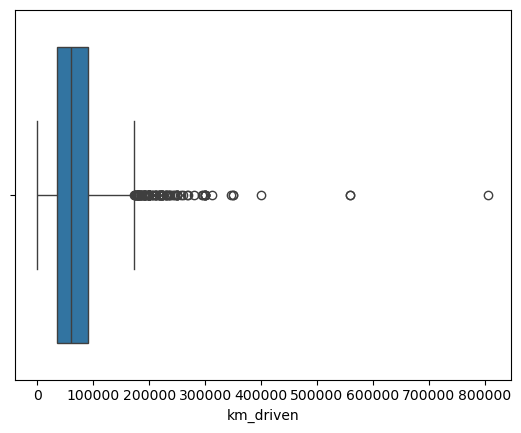

In [22]:
import seaborn as sns
sns.boxplot(x="km_driven",data=df)

In [23]:
y=df["selling_price"]
y

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64

In [24]:
x=df.drop(columns="selling_price",axis=1)
x

,name,year,km_driven,fuel,seller_type,transmission,owner
0,775,2007,70000,4,1,1,0
1,1041,2007,50000,4,1,1,0
2,505,2012,100000,1,1,1,0
3,118,2017,46000,4,1,1,0
4,279,2014,141000,1,1,1,2
...,...,...,...,...,...,...,...
4335,602,2014,80000,1,1,1,2
4336,601,2014,80000,1,1,1,2
4337,777,2009,83000,4,1,1,2
4338,381,2016,90000,1,1,1,0


In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
obj_1=StandardScaler()
x_train_scaled=obj_1.fit_transform(x_train)
x_test_scaled=obj_1.transform(x_test)

# LINEAR REGRESSION

In [26]:
model1=LinearRegression()
model1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
#testing accuracy
y_pred=model1.predict(x_test)
ff=r2_score(y_test,y_pred)
ff

0.39596976258883976

In [28]:
#training accuracy
y_train_pred=model1.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training

-0.16706989748048806

In [29]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 221820.84345081868
MSE : 184332080354.48502
RMSE : 429339.1204566444
R2 Score : 0.39596976258883976


# KNN

In [30]:
model2=KNeighborsRegressor()
model2.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
#testing accuracy
y_pred=model2.predict(x_test)
ff=r2_score(y_test,y_pred)
ff

0.2684643223312666

In [32]:
#training accuracy
y_train_pred=model2.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training

0.3388711113927233

In [33]:
param_dist ={'n_neighbors': [3,5,7], 'metric': ['euclidean', 'manhattan'] }

rf =KNeighborsRegressor()

rand_search = RandomizedSearchCV(rf, param_distributions = param_dist,n_iter=5, cv=5,verbose=1, n_jobs=-1)

rand_search.fit(x_train, y_train)
print("Best Hyperparameters:")
print(rand_search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters:
{'n_neighbors': 3, 'metric': 'manhattan'}


In [34]:
model23=KNeighborsRegressor(metric='manhattan')
model23.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [35]:
#testing accuracy
y_pred=model23.predict(x_test)
ff=r2_score(y_test,y_pred)
ff

0.2671776394333484

In [36]:
#training accuracy
y_train_pred=model23.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training

0.35320124348389226

In [37]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 238846.37419354837
MSE : 223635609423.28348
RMSE : 472901.268155715
R2 Score : 0.2671776394333484


# SVR

In [38]:
model3=SVR()
model3.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [39]:
#testing accuracy
y_pred=model3.predict(x_test)
ff=r2_score(y_test,y_pred)
ff

-0.06343509912092027

In [40]:
#training accuracy
y_train_pred=model3.predict(x_train)
final_training=r2_score(y_train_pred,y_train)
final_training

-11318685.789118884

In [41]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 289482.1011633969
MSE : 324528793431.0876
RMSE : 569674.2871422999
R2 Score : -0.06343509912092027


In [ ]:
for svr hyperparameter not wroking 

In [42]:
df2

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner


In [43]:
df2["name"]=obj.fit_transform(df2["name"])
df2["fuel"]=obj.fit_transform(df2["fuel"])
df2["seller_type"]=obj.fit_transform(df2["seller_type"])
df2["transmission"]=obj.fit_transform(df2["transmission"])
df2["owner"]=obj.fit_transform(df2["owner"])

In [44]:
df2

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,775,2007,60000,70000,4,1,1,0
1,1041,2007,135000,50000,4,1,1,0
2,505,2012,600000,100000,1,1,1,0
3,118,2017,250000,46000,4,1,1,0
4,279,2014,450000,141000,1,1,1,2
...,...,...,...,...,...,...,...,...
4335,602,2014,409999,80000,1,1,1,2
4336,601,2014,409999,80000,1,1,1,2
4337,777,2009,110000,83000,4,1,1,2
4338,381,2016,865000,90000,1,1,1,0


In [45]:
x2_train,x2_test,y2_train,y2_test=train_test_split(x,y,test_size=0.2,random_state=42)

# DECISION TREE

In [46]:
model4= DecisionTreeRegressor()
model4.fit(x2_train,y2_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [49]:
#testing accuracy
y2_pred=model4.predict(x2_test)
ff=r2_score(y2_test,y2_pred)
ff

0.5492840801830665

In [50]:
#training accuracy
y2_train_pred=model4.predict(x2_train)
final_training=r2_score(y2_train_pred,y2_train)
final_training

0.99990958171569

In [51]:
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}
grid_search = GridSearchCV(
    estimator=model4,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(x2_train, y2_train)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y2_pred = best_model.predict(x2_test)
print("Accuracy:",r2_score(y2_test,y2_pred))

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.3723657256714007


C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [52]:
model45= DecisionTreeRegressor(max_depth=3, min_samples_leaf= 1, min_samples_split= 2)
model45.fit(x2_train,y2_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [53]:
#testing accuracy
y2_pred=model45.predict(x2_test)
ff=r2_score(y2_test,y2_pred)
ff

0.3723657256714007

In [54]:
#training accuracy
y2_train_pred=model45.predict(x2_train)
final_training=r2_score(y2_train_pred,y2_train)
final_training

0.3098076685317739

In [55]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 289482.1011633969
MSE : 324528793431.0876
RMSE : 569674.2871422999
R2 Score : -0.06343509912092027


# RANDOM FOREST

In [56]:
model5=RandomForestRegressor()
model5.fit(x2_train, y2_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
#testing accuracy
y2_pred=model5.predict(x2_test)
ff=r2_score(y2_test,y2_pred)
ff

0.6872213279669818

In [58]:
#training accuracy
y2_train_pred=model5.predict(x2_train)
final_training=r2_score(y2_train_pred,y2_train)
final_training

0.9669149181226774

In [59]:
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

rf = RandomForestRegressor()

rand_search = RandomizedSearchCV(rf, param_distributions = param_dist,n_iter=5, cv=5,verbose=1, n_jobs=-1)

rand_search.fit(x2_train, y2_train)
print("Best Hyperparameters:")
print(rand_search.best_params_)
print("Accuracy:",r2_score(y2_test,y2_pred))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters:
{'max_depth': 18, 'n_estimators': 324}
Accuracy: 0.6872213279669818


In [61]:
model56=RandomForestRegressor(max_depth=18, n_estimators= 324)
model56.fit(x2_train, y2_train)

,n_estimators,324
,criterion,'squared_error'
,max_depth,18
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
#testing accuracy
y2_pred=model56.predict(x2_test)
ff=r2_score(y2_test,y2_pred)
ff

0.6942426716760453

In [63]:
#training accuracy
y2_train_pred=model56.predict(x2_train)
final_training=r2_score(y2_train_pred,y2_train)
final_training

0.9685596142031825

In [64]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 289482.1011633969
MSE : 324528793431.0876
RMSE : 569674.2871422999
R2 Score : -0.06343509912092027


In [65]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(x2_train, y2_train)
y2_pred = xgb.predict(x2_test)

print("XGBoost Test Accuracy:",r2_score (y2_test, y2_pred))

XGBoost Test Accuracy: 0.7370554208755493


In [66]:
#training accuracy
y2_train_pred=xgb.predict(x2_train)
final_training=r2_score(y2_train_pred,y2_train)
final_training

0.9905078411102295

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
}

xgb = XGBRegressor()

rand_search = RandomizedSearchCV(XGBRegressor(),param_grid,n_iter=30,cv=5,scoring='accuracy',n_jobs=-1)

rand_search.fit(x2_train, y2_train)
print("Best Hyperparameters:")
print(rand_search.best_params_)
print("Accuracy:",r2_score(y2_test,y2_pred))

C:\Users\mohan\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Hyperparameters:
{'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05}
Accuracy: 0.7370554208755493


In [68]:
from xgboost import XGBRegressor

xgb2= XGBRegressor(n_estimators=500,max_depth=10, learning_rate=0.05)

xgb2.fit(x2_train, y2_train)
y2_pred = xgb2.predict(x2_test)

print("XGBoost Test Accuracy:",r2_score (y2_test, y2_pred))

XGBoost Test Accuracy: 0.6877933740615845


In [69]:
#training accuracy
y2_train_pred=xgb2.predict(x2_train)
final_training=r2_score(y2_train_pred,y2_train)
final_training

0.9992083311080933

In [70]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 289482.1011633969
MSE : 324528793431.0876
RMSE : 569674.2871422999
R2 Score : -0.06343509912092027
